# **Cell-Cell Interaction Analysis with CellChat**
---
2026-07-21

#### **Load library**

In [1]:
library(Seurat)
library(CellChat)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggplot2



#### **Load the data**

In [3]:
seurat <- readRDS("data/cellchat/HLCA_pulmonary_fibrosis_immune_sampled.rds")
seurat

An object of class Seurat 
19354 features across 7408 samples within 1 assay 
Active assay: RNA (19354 features, 0 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

#### **UMAP visualization**

In [ ]:
options(repr.plot.format = "png", jupyter.plot_mimetypes = c("image/png", "image/jpeg"))

In [5]:
ct_order <- c("Monocyte", "Macrophage", "T cell", "NK cell")
seurat$celltype <- factor(seurat$celltype, levels = ct_order)

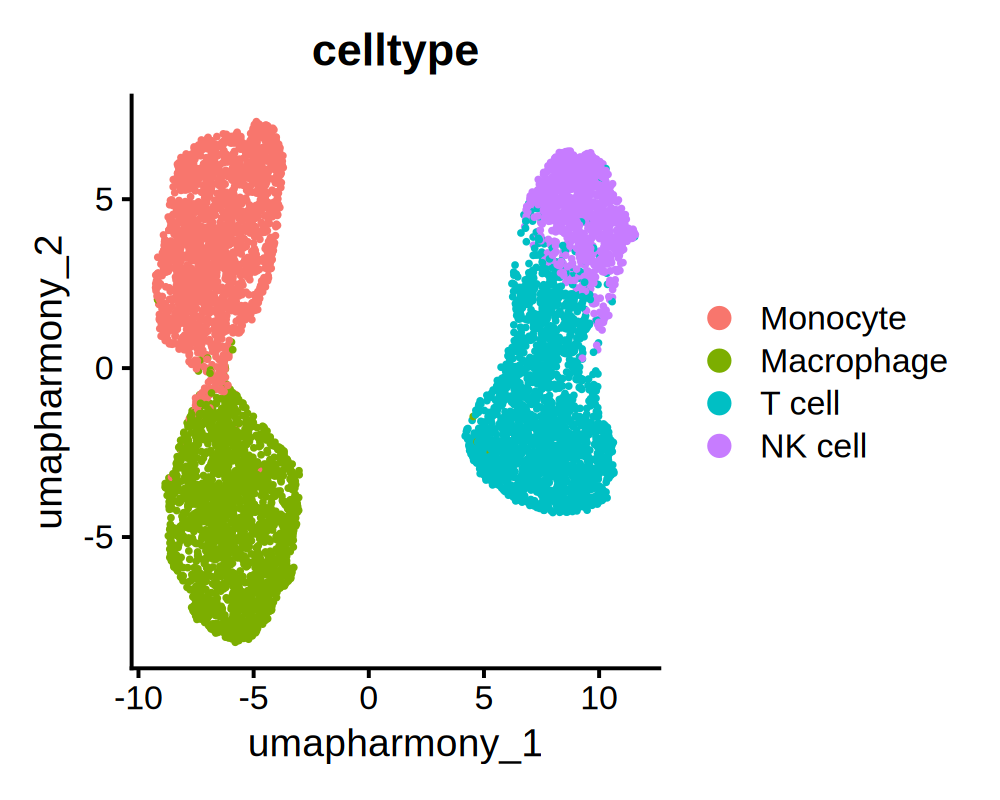

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)
DimPlot(seurat, group.by = "celltype", reduction = "umap.harmony")

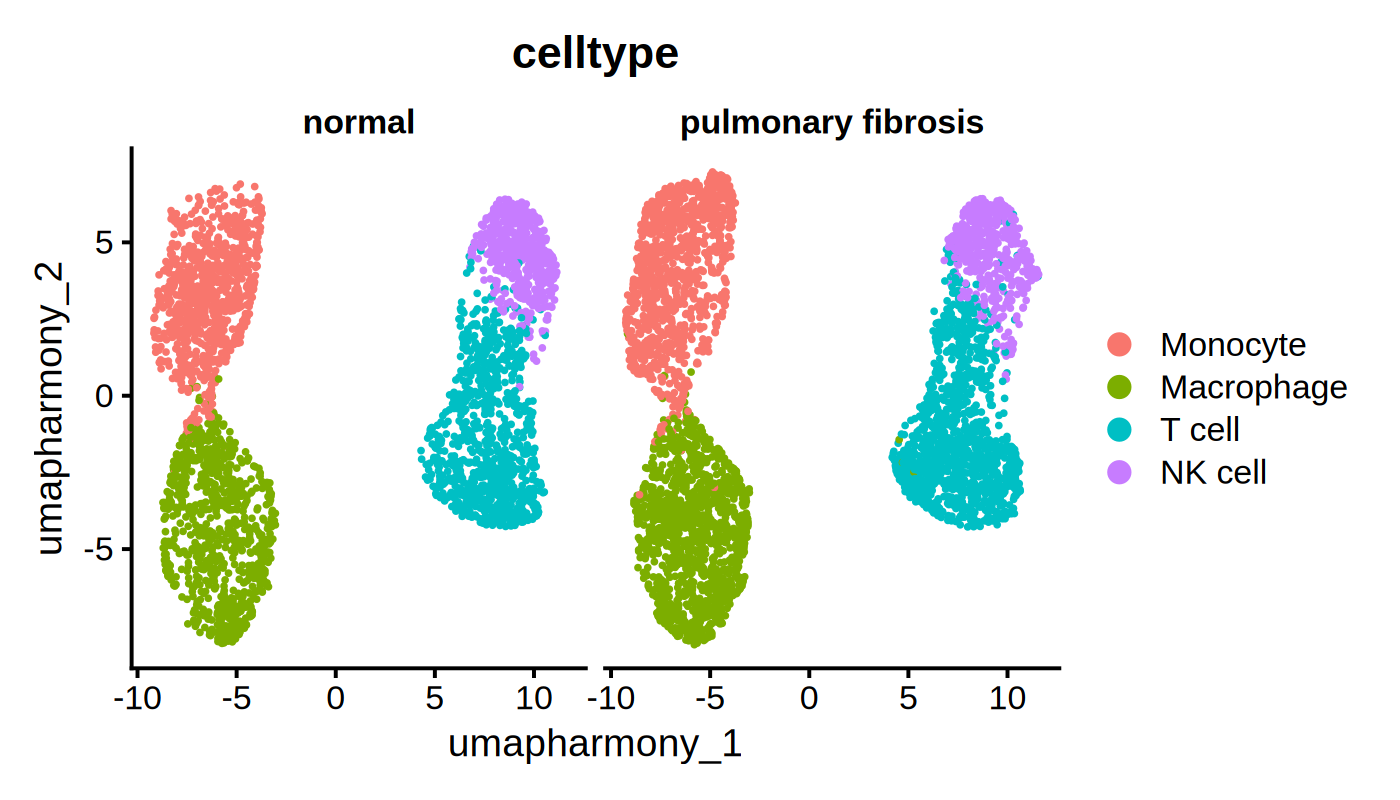

In [ ]:
options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 200)
DimPlot(seurat, group.by = "celltype", reduction = "umap.harmony", split.by = "disease")

---
### **Input data processing**
#### **1-1. Create CellChat object from Seurat object**

In [8]:
seurat_PF <- subset(seurat, subset = disease == "pulmonary fibrosis")
cellchat_PF <- createCellChat(object = seurat_PF, group.by = "celltype", assay = "RNA")

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 


Warning message in createCellChat(object = seurat_PF, group.by = "celltype", assay = "RNA"):
“The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Monocyte, Macrophage, T cell, NK cell 


#### **1-2. (Do not run) Create CellChat object from expression matrix and metadata**

In [9]:
expr <- seurat[["RNA"]]$data
meta <- seurat@meta.data

cells_PF <- rownames(meta)[meta$disease == "pulmonary fibrosis"]

expr_PF <- expr[, cells_PF]
meta_PF <- meta[cells_PF,]
meta_PF$celltype <- as.character(meta_PF$celltype)

cellchat_PF <- createCellChat(object = expr_PF, meta = meta_PF, group.by = "celltype")

[1] "Create a CellChat object from a data matrix"


Warning message in createCellChat(object = expr_PF, meta = meta_PF, group.by = "celltype"):
“The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Macrophage, Monocyte, NK cell, T cell 


#### **2. Set the ligand-receptor interaction database**

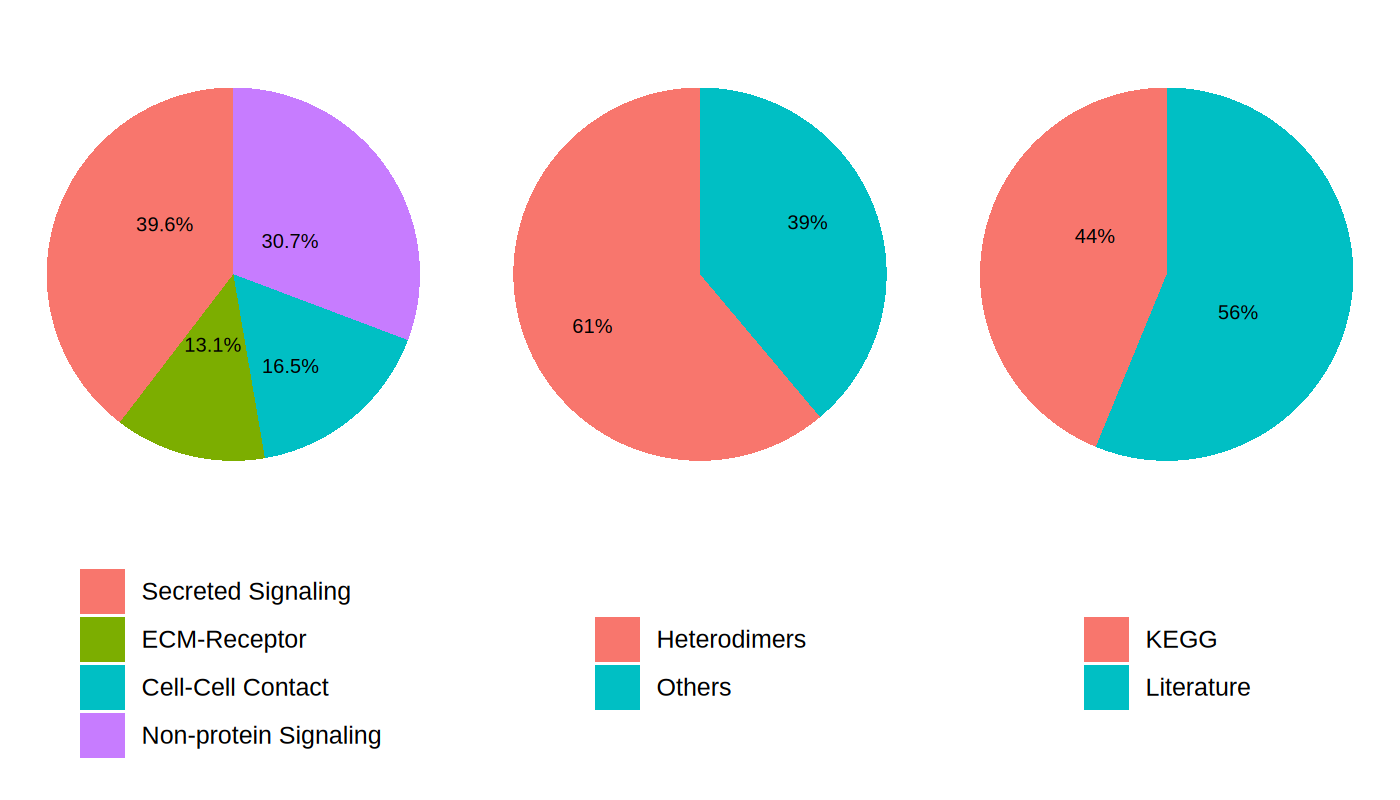

In [10]:
CellChatDB <- CellChatDB.human # # use CellChatDB.mouse if running on mouse data
showDatabaseCategory(CellChatDB)

#### **3. Subset the expression data using CellChatDB genes**

In [11]:
cellchat_PF@DB <- CellChatDB
cellchat_PF <- subsetData(cellchat_PF)

#### **4. Identify over-expressed ligands/receptors and L-R interactions in each cell group**

In [12]:
cellchat_PF <- identifyOverExpressedGenes(cellchat_PF)
cellchat_PF <- identifyOverExpressedInteractions(cellchat_PF)

The number of highly variable ligand-receptor pairs used for signaling inference is 871 


#### **5. (Optional) Smooth the gene expression because of shallow sequencing depth**

In [13]:
cellchat_PF <- smoothData(cellchat_PF, adj = PPI.human)

---
### **Inference of cell-cell communication networks**
#### **1. Compute the communication probability**

In [14]:
cellchat_PF <- computeCommunProb(cellchat_PF, raw.use = FALSE) # Set raw.use = FALSE to use the smoothed data

triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-07-01 05:50:01.156411]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-07-01 05:51:27.089319]"


#### **2. Filter the cell-cell interaction, based on the number of cells in each group**

In [15]:
cellchat_PF <- filterCommunication(cellchat_PF, min.cells = 0)

#### **3. Extract the inferred cellular communication network as a data frame**

In [16]:
df_net_PF <- subsetCommunication(cellchat_PF)

In [17]:
head(df_net_PF, 6)

,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>,<chr>
1,Macrophage,Macrophage,TGFB1,TGFbR1_R2,0.001743110,0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
2,Monocyte,Macrophage,TGFB1,TGFbR1_R2,0.001484032,0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
3,NK cell,Macrophage,TGFB1,TGFbR1_R2,0.001493103,0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
4,Macrophage,Monocyte,TGFB1,TGFbR1_R2,0.001650336,0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
5,Macrophage,NK cell,TGFB1,TGFbR1_R2,0.001622703,0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
6,Macrophage,T cell,TGFB1,TGFbR1_R2,0.001648001,0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350


#### **4. Infer the cell-cell communication at a signaling pathway level**

In [18]:
cellchat_PF <- computeCommunProbPathway(cellchat_PF)

#### **5. Calculate the aggregated cell-cell communication network**

In [19]:
cellchat_PF <- aggregateNet(cellchat_PF)

#### **6. Save the CellChat object**

In [20]:
saveRDS(cellchat_PF, file = "cellchat_lung_PF.rds")

---
### **Visualization**
#### **Circle plot**

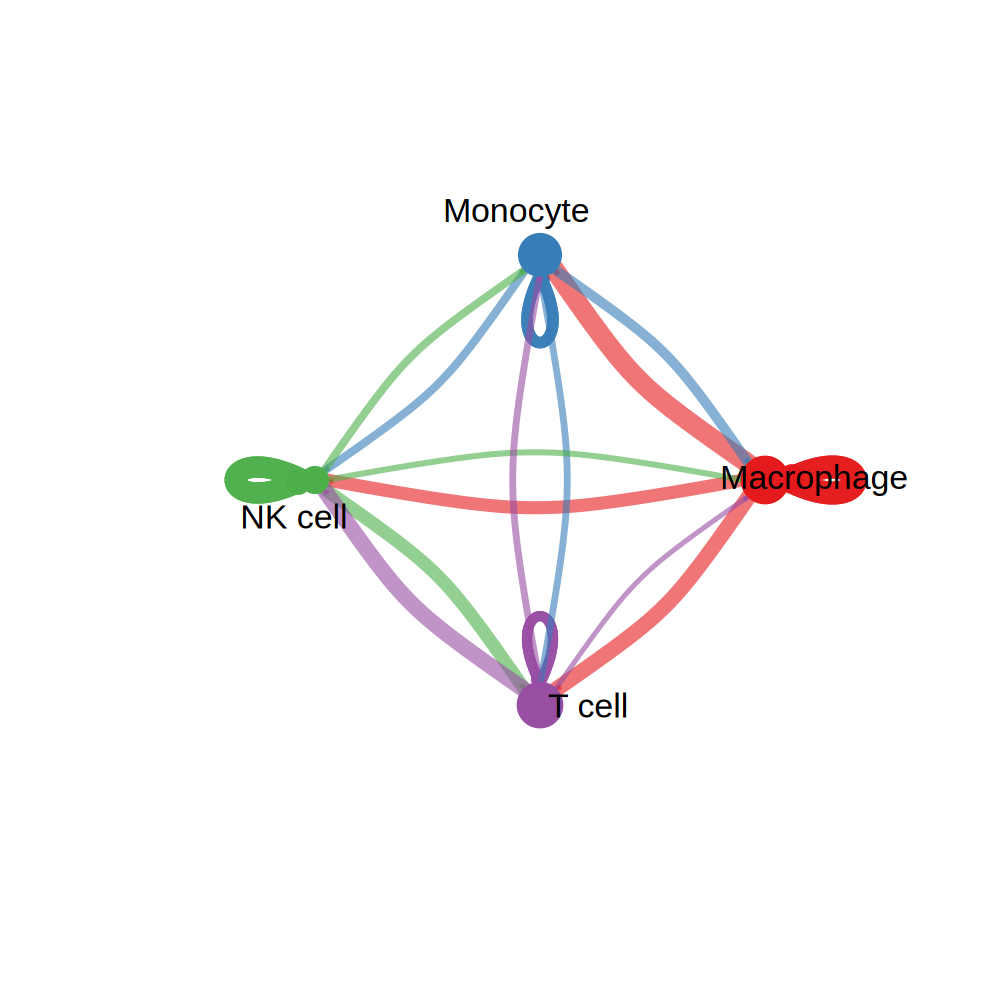

In [21]:
groupSize_PF <- as.numeric(table(cellchat_PF@idents))

options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)
invisible(
    netVisual_circle(cellchat_PF@net$weight, vertex.weight = groupSize_PF, weight.scale = T, label.edge= F)
    )

In [22]:
cellchat_PF <- netAnalysis_computeCentrality(cellchat_PF, slot.name = "netP")

In [23]:
names(cellchat_PF@netP$centr)

[1] "CCL"           "CLEC"          "GALECTIN"      "MIF"          
 [5] "FN1"           "ANNEXIN"       "ICAM"          "SPP1"         
 [9] "VISFATIN"      "APP"           "Prostaglandin" "CypA"         
[13] "THBS"          "RESISTIN"      "ApoE"          "VTN"          
[17] "IL2"           "Cholesterol"   "PLAU"          "GRN"          
[21] "TGFb"          "LT"            "PECAM1"        "IL1"          
[25] "LAIR1"         "CD40"          "CD6"           "SELPLG"       
[29] "EGF"           "BAFF"          "IL10"          "COMPLEMENT"   
[33] "BTLA"          "CD96"          "IL16"          "LIGHT"        
[37] "IL6"           "CSF"           "SIRP"          "CXCL"         
[41] "CD45"          "IL4"           "IGFBP"         "CDH1"         
[45] "SEMA3"         "PVR"           "CD86"          "ApoB"         
[49] "VEGF"          "BAG"           "DHEA"          "DHT"          
[53] "SEMA4"         "TRAIL"         "CD23"          "L1CAM"        
[57] "CD48"          "PARs"          "Desmosterol"   "CD80"         
[61] "OSM"           "NRG"           "NOTCH"         "GAS"          
[65] "CD46"          "LIFR"          "ApoA"          "IGF"          
[69] "MPZ"           "FASLG"         "CDH"           "DHEAS"        
[73] "PDGF"          "EPHA"          "BMP"           "FLT3"

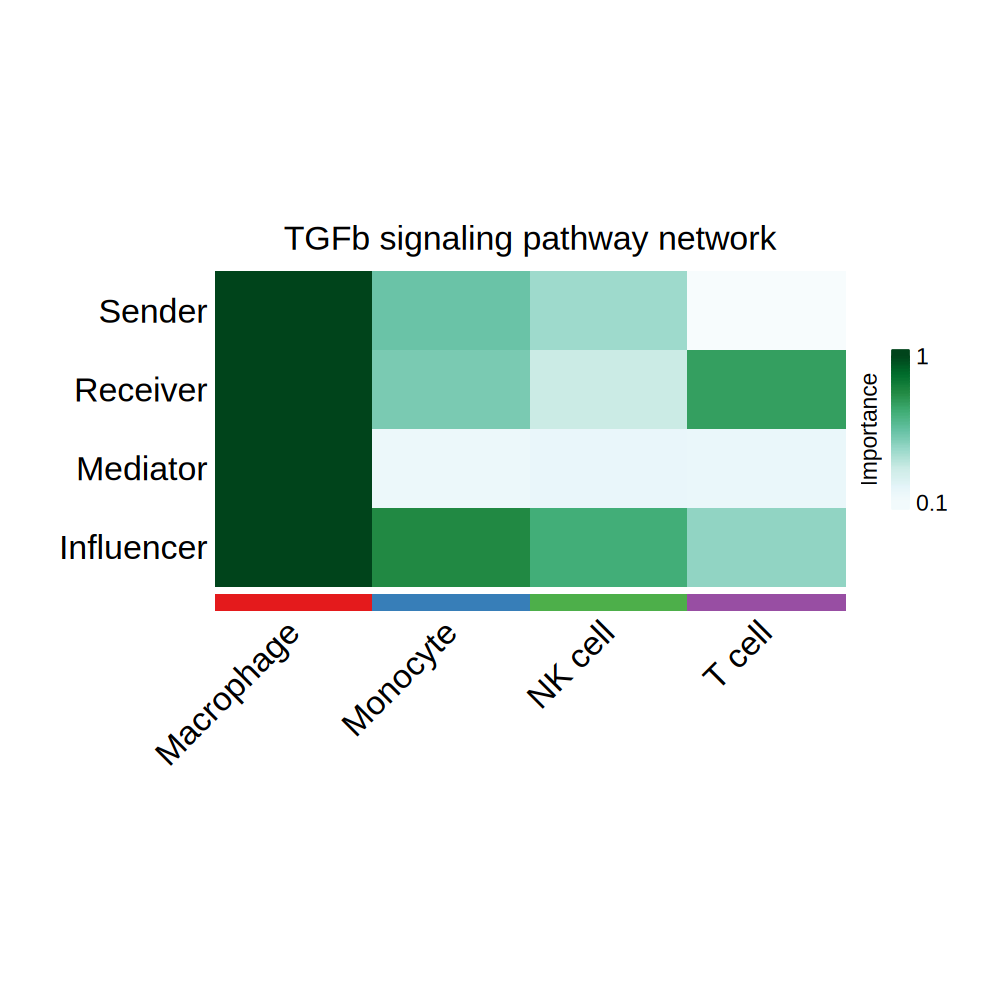

In [24]:
pathways.show <- "TGFb"
netAnalysis_signalingRole_network(cellchat_PF, signaling = pathways.show, width = 8, height = 4, font.size = 12, font.size.title = 12)

Comparing communications on a single object 




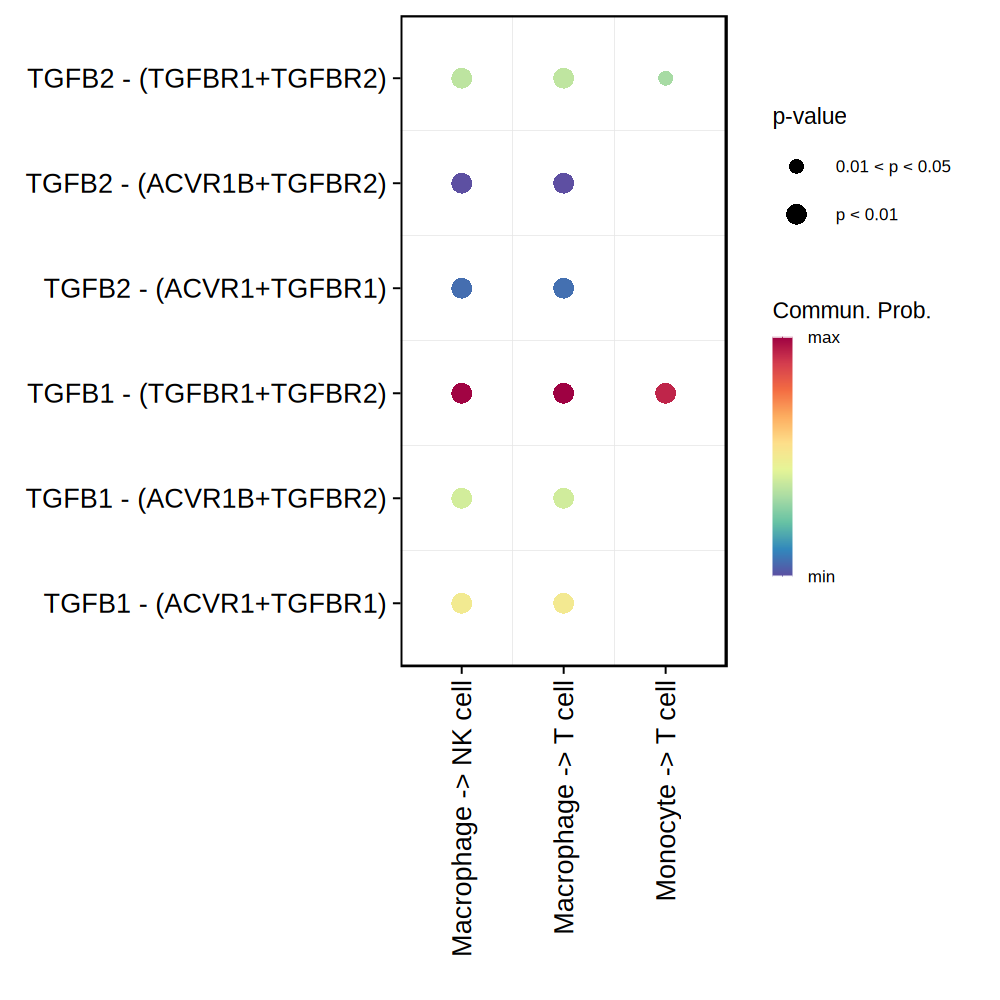

In [25]:
ct_source <- c("Monocyte", "Macrophage")
ct_target <- c("T cell", "NK cell")

netVisual_bubble(cellchat_PF, sources.use = ct_source, targets.use = ct_target, signaling = pathways.show, remove.isolate = TRUE, font.size = 12)

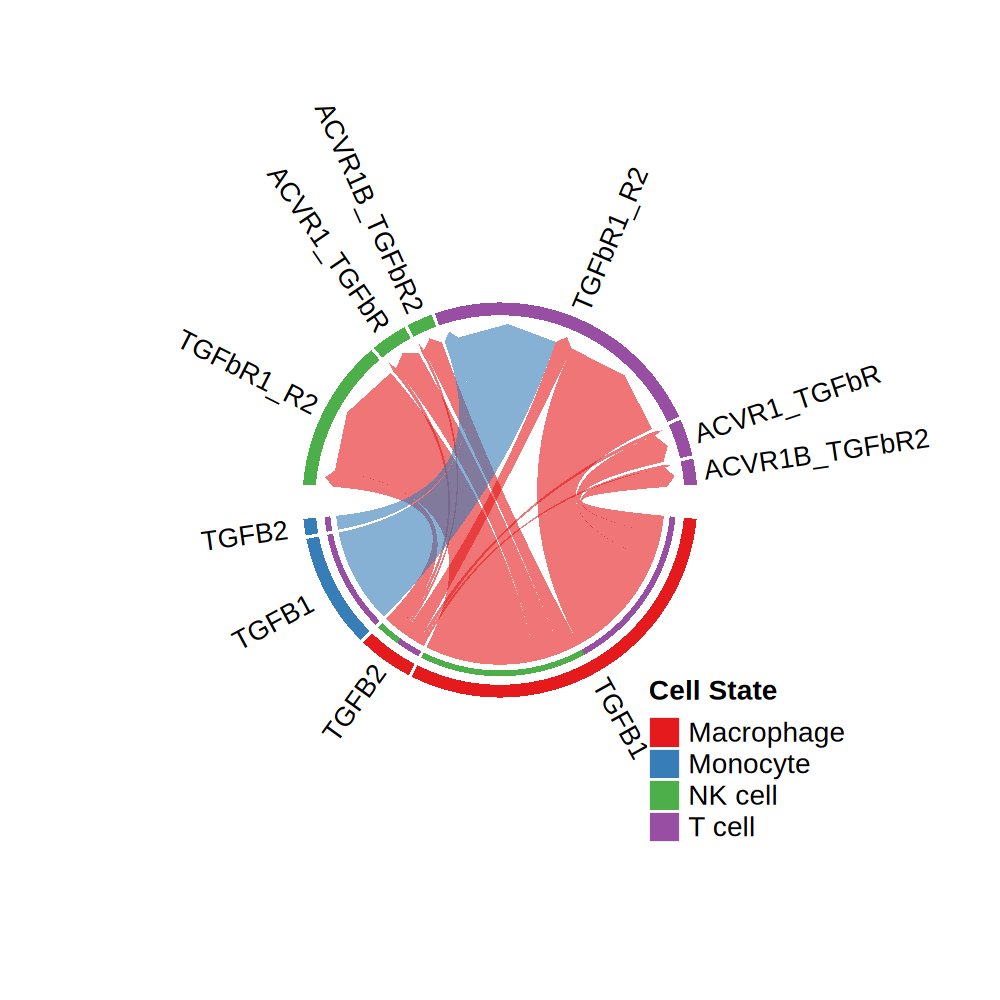

In [26]:
invisible(
    netVisual_chord_gene(cellchat_PF, sources.use = ct_source, targets.use = ct_target, signaling = pathways.show)
    )

---
### **Process same process for normal group**
#### **1. Input data processing & Running CellChat**

In [27]:
seurat_NM <- subset(seurat, subset = disease == "normal")
cellchat_NM <- createCellChat(object = seurat_NM, group.by = "celltype", assay = "RNA")

cellchat_NM@DB <- CellChatDB

cellchat_NM <- subsetData(cellchat_NM)

cellchat_NM <- identifyOverExpressedGenes(cellchat_NM)
cellchat_NM <- identifyOverExpressedInteractions(cellchat_NM)

cellchat_NM <- smoothData(cellchat_NM, adj = PPI.human)

cellchat_NM <- computeCommunProb(cellchat_NM, raw.use = FALSE)
cellchat_NM <- filterCommunication(cellchat_NM, min.cells = 0)
cellchat_NM <- computeCommunProbPathway(cellchat_NM)
cellchat_NM <- aggregateNet(cellchat_NM)

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Monocyte, Macrophage, T cell, NK cell 
The number of highly variable ligand-receptor pairs used for signaling inference is 983 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-07-01 05:51:42.710019]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-07-01 05:53:01.309]"


#### **2. Visualization**

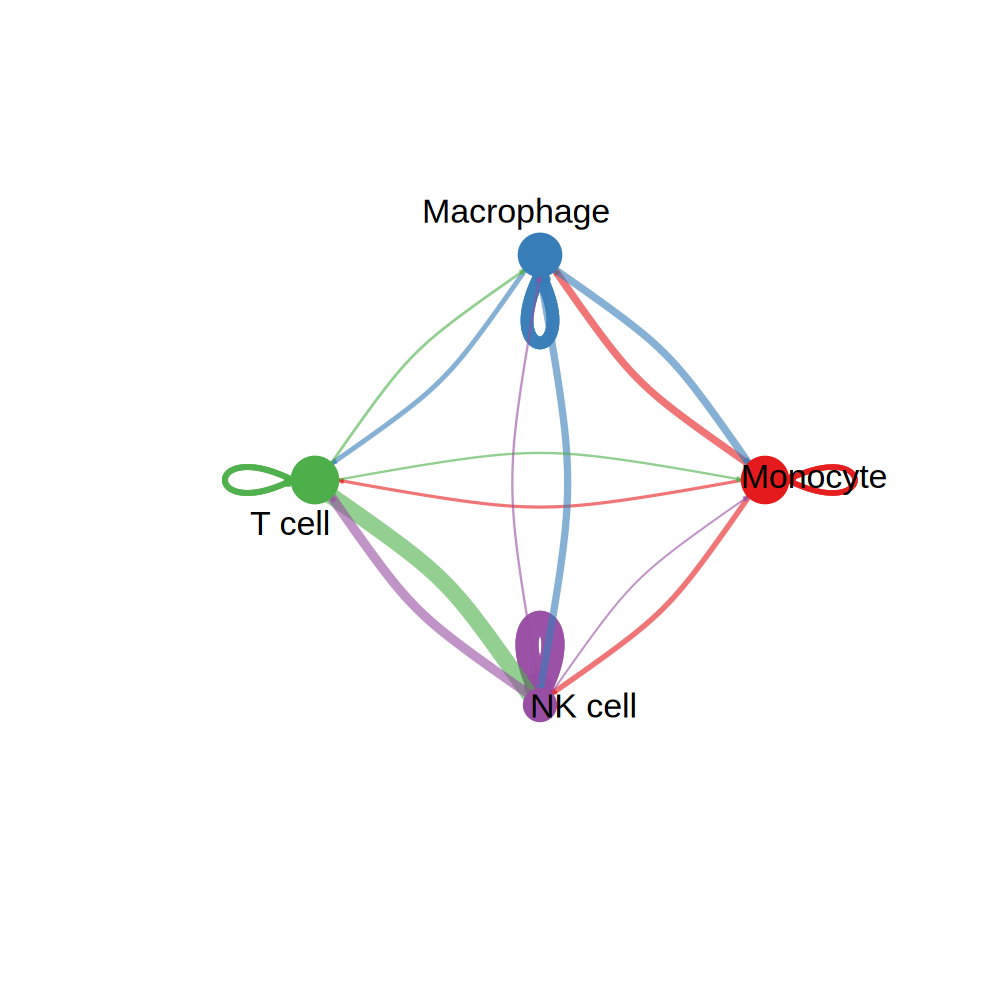

In [28]:
groupSize_NM <- as.numeric(table(cellchat_NM@idents))

invisible(
    netVisual_circle(cellchat_NM@net$weight, vertex.weight = groupSize_NM, weight.scale = T, label.edge= F)
    )

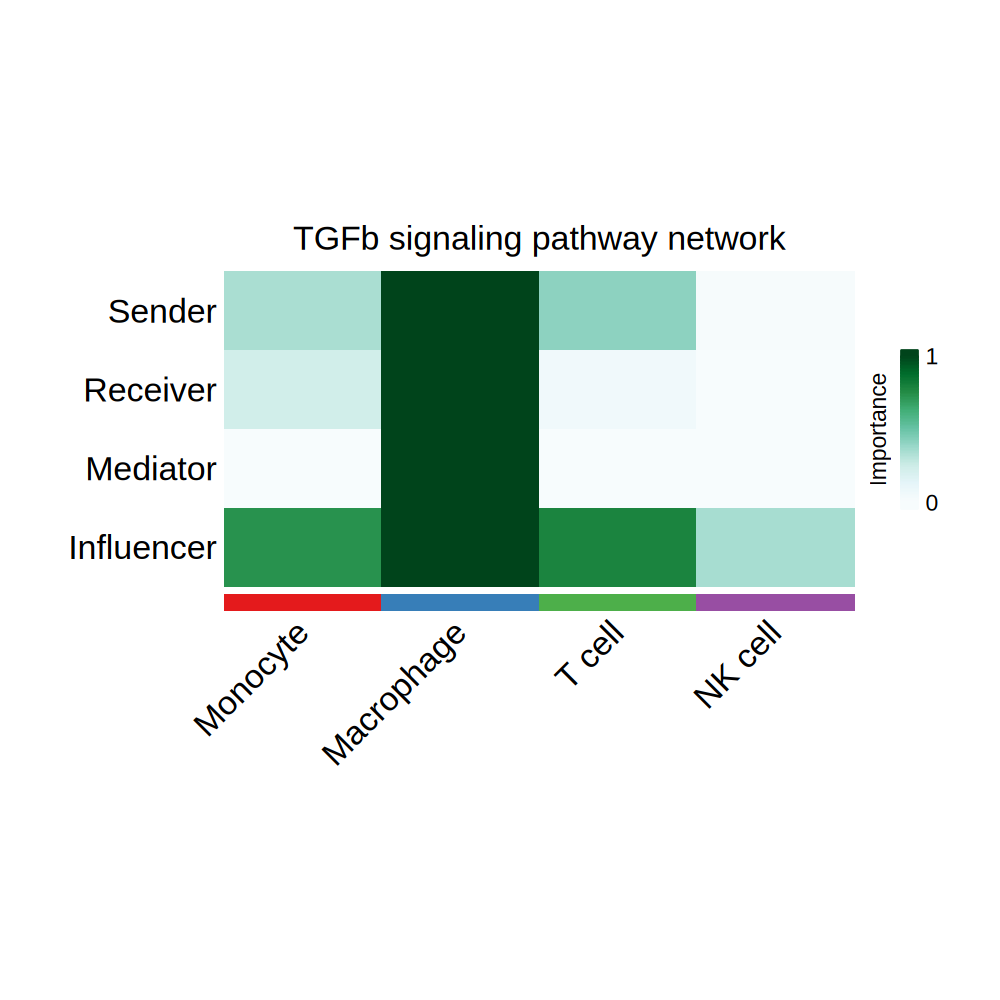

In [29]:
# Compute centrality
cellchat_NM <- netAnalysis_computeCentrality(cellchat_NM, slot.name = "netP")

netAnalysis_signalingRole_network(cellchat_NM, signaling = pathways.show, width = 8, height = 4, font.size = 12, font.size.title = 12)

Comparing communications on a single object 




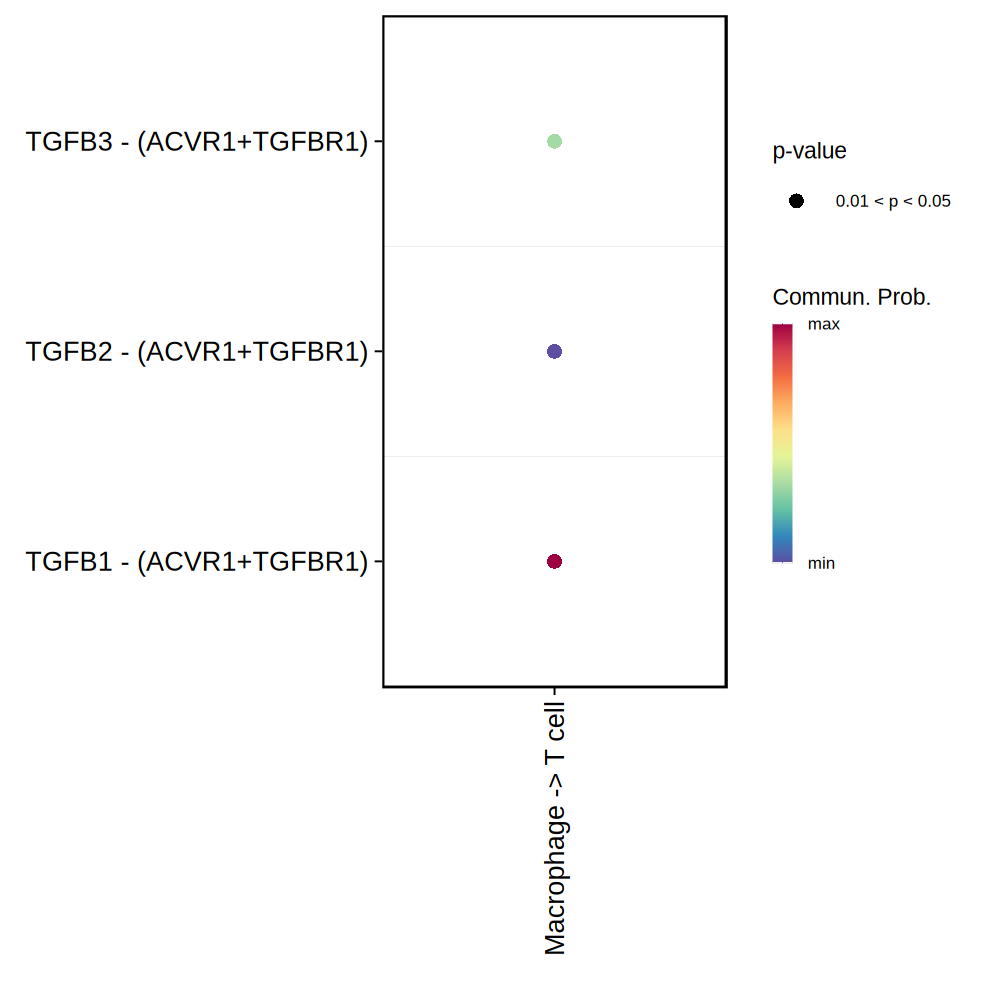

In [30]:
netVisual_bubble(cellchat_NM, sources.use = ct_source, targets.use = ct_target, signaling = pathways.show, remove.isolate = TRUE, font.size = 12)

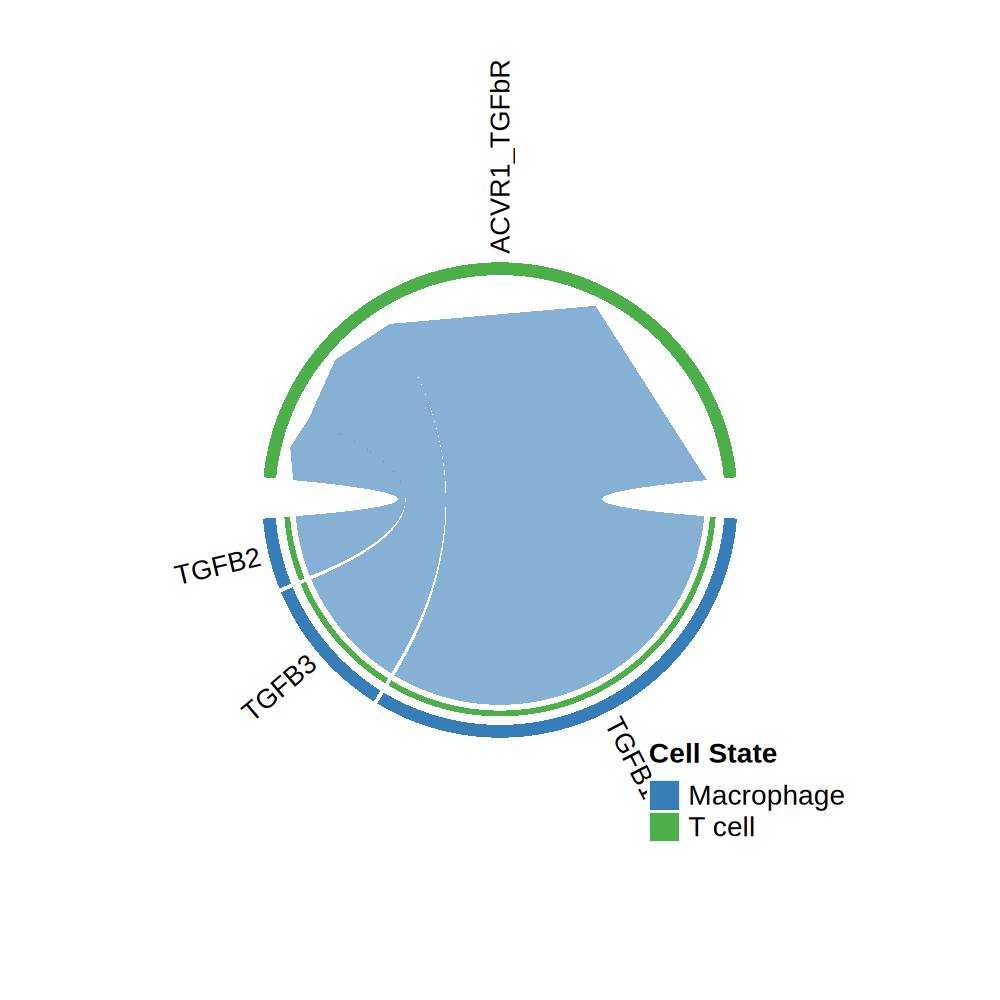

In [31]:
invisible(
    netVisual_chord_gene(cellchat_NM, sources.use = ct_source, targets.use = ct_target, signaling = pathways.show)
    )

---
### **Reference**
Jin, S., Guerrero-Juarez, C. F., Zhang, L., Chang, I., Ramos, R., Kuan, C. H., … & Nie, Q. (2021). Inference and analysis of cell-cell communication using CellChat. Nature communications, 12(1), 1-20.

Jin, S., Plikus, M.V. & Nie, Q. (2025). CellChat for systematic analysis of cell–cell communication from single-cell transcriptomics. Nat Protoc, 20, 180–219.

Sikkema, L., Ramírez-Suástegui, C., Strobl, D.C., … & Theis, F.J. (2023). An integrated cell atlas of the lung in health and disease. Nat Med, 29, 1563–1577.

In [32]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] future_1.70.0       CellChat_2.2.0.9001 Biobase_2.70.0     
 [4] BiocGenerics_0.56.0 generics_0.1.4      ggplot2_4.0.3      
 [7] igraph_2.3.2        dplyr_1.2.1         Seurat_5.5.0       
[10] SeuratObject_5.4.0  sp_2.2-1           

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.23       splines_4